# 📦 Exercícios Práticos: NumPy e Pandas

**Aluno:** Matheus Sousa Marinho &nbsp;·&nbsp; **Matrícula:** 202206132
**Disciplina:** LIA 1 (2026/2) &nbsp;·&nbsp; **Entrega:** exercícios da aula 1.1

Resolução dos três desafios propostos ao final de
`1_1_Python_Basics_A1_Numpy_e_Pandas.ipynb`.

## 1. Preparação

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Identidade visual definida uma única vez, para que os gráficos da seção 4 saiam
# coerentes entre si. A paleta 'colorblind' é segura para daltonismo.
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.titlesize": 13, "axes.titleweight": "bold", "grid.alpha": 0.3,
})
AZUL, LARANJA, VERDE = sns.color_palette("colorblind")[:3]
CINZA = "#8C8C8C"


def reais(valor, casas=0):
    """Formata no padrão brasileiro de moeda: 66264 vira 'R$ 66.264'."""
    if pd.isna(valor):
        return "sem valor"
    # O 'X' é posição temporária para que a troca de separadores não desfaça a si mesma
    texto = f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return "R$ " + texto


def pct(proporcao, casas=1):
    """Formata uma proporção como percentual brasileiro: 0.297 vira '29,7%'."""
    return f"{proporcao:.{casas}%}".replace(".", ",")


print(f"numpy {np.__version__} | pandas {pd.__version__} | "
      f"matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}")

numpy 2.2.6 | pandas 2.2.3 | matplotlib 3.10.0 | seaborn 0.13.2


---

# 2. 💪 Desafio 1: Análise de Dados de Vendas

> 1. Qual vendedor teve o maior número de vendas?
> 2. Qual região teve o maior faturamento total?
> 3. Qual é o produto mais vendido em quantidade?
> 4. Qual é a média de vendas por vendedor?

### 2.1 Reconstrução dos dados

Reproduzo o bloco da aula, com a mesma semente, para chegar aos mesmos números.

In [2]:
np.random.seed(42)

df_vendas = pd.DataFrame({
    "Vendedor": ["Ana", "João", "Pedro", "Ana", "João", "Pedro", "Ana", "João", "Pedro", "Ana"] * 3,
    "Produto": ["Notebook", "Mouse", "Teclado", "Monitor", "Headset"] * 6,
    "Regiao": ["Norte", "Sul", "Nordeste", "Centro-Oeste", "Sudeste"] * 6,
    "Vendas": np.random.randint(1000, 10000, 30),
    "Quantidade": np.random.randint(1, 20, 30),
})

print(f"{len(df_vendas)} registros, {df_vendas.shape[1]} colunas")
df_vendas.head()

30 registros, 5 colunas


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,8270,12
1,João,Mouse,Sul,1860,3
2,Pedro,Teclado,Nordeste,6390,5
3,Ana,Monitor,Centro-Oeste,6191,19
4,João,Headset,Sudeste,6734,7


### 2.2 Diagnóstico: o que a construção dos dados impõe

As três colunas de texto vêm de listas repetidas com o operador `*`, e o tamanho do
ciclo de cada lista decide quais combinações são possíveis.

In [3]:
# 'Produto' e 'Regiao' vêm de listas de 5 itens repetidas 6 vezes. Como os dois ciclos
# têm o mesmo tamanho, a posição i sempre casa o mesmo produto com a mesma região.
cruzamento = pd.crosstab(df_vendas["Produto"], df_vendas["Regiao"])
display(cruzamento)
print(f"Combinações possíveis: {cruzamento.size} | que realmente aparecem: {(cruzamento > 0).sum().sum()}")

# A lista de vendedores tem ciclo de 10, e Ana ocupa 4 dessas 10 posições.
contagem = df_vendas["Vendedor"].value_counts()
print("\n" + " | ".join(f"{n}: {r} registros ({pct(r / len(df_vendas), 0)})" for n, r in contagem.items()))

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Produto,,,,,
Headset,0,0,0,6,0
Monitor,6,0,0,0,0
Mouse,0,0,0,0,6
Notebook,0,0,6,0,0
Teclado,0,6,0,0,0


Combinações possíveis: 25 | que realmente aparecem: 5

Ana: 12 registros (40%) | João: 9 registros (30%) | Pedro: 9 registros (30%)


A tabela cruzada é uma **diagonal**: só 5 das 25 combinações existem. `Notebook` só é
vendido no `Norte`, `Mouse` só no `Sul`, e assim por diante. Na prática,
`groupby("Regiao")` e `groupby("Produto")` devolvem os mesmos números com rótulos
trocados, então **as perguntas 2 e 3 interrogam o mesmo eixo**.

E Ana entra na disputa com um terço a mais de oportunidades, por construção da lista.
Qualquer soma por vendedor carrega esse desequilíbrio embutido.

### 2.3 Pergunta 1: qual vendedor teve o maior número de vendas?

*"Número de vendas"* pode significar **quantas** vendas cada pessoa fez ou **quanto**
cada uma vendeu. Como os vendedores não têm o mesmo número de registros, o ticket médio
é a terceira leitura necessária: ele neutraliza a diferença de oportunidades.

In [4]:
por_vendedor = (
    df_vendas.groupby("Vendedor")
    .agg(registros=("Vendas", "size"), faturamento=("Vendas", "sum"),
         ticket_medio=("Vendas", "mean"), itens=("Quantidade", "sum"))
    .sort_values("faturamento", ascending=False)
)
display(por_vendedor.round(2))

lider_total = por_vendedor["faturamento"].idxmax()
lider_medio = por_vendedor["ticket_medio"].idxmax()
vantagem = por_vendedor.loc[lider_total, "faturamento"] / por_vendedor.loc[lider_medio, "faturamento"] - 1

print(f"Por volume: {lider_total} ({reais(por_vendedor.loc[lider_total, 'faturamento'])}, "
      f"{pct(vantagem)} acima de {lider_medio})")
print(f"Por ticket médio: {lider_medio} ({reais(por_vendedor.loc[lider_medio, 'ticket_medio'], 2)})")
print(f"A vantagem de {lider_total} vem de "
      f"{por_vendedor.loc[lider_total, 'registros'] - por_vendedor.loc[lider_medio, 'registros']} "
      f"vendas a mais, não de vender melhor.")

,registros,faturamento,ticket_medio,itens
Vendedor,,,,
Ana,12,66264,5522.00,156
Pedro,9,51098,5677.56,59
João,9,40731,4525.67,77


Por volume: Ana (R$ 66.264, 29,7% acima de Pedro)
Por ticket médio: Pedro (R$ 5.677,56)
A vantagem de Ana vem de 3 vendas a mais, não de vender melhor.


**Resposta.** As duas leituras discordam. **Ana** lidera em volume (12 vendas,
R$ 66.264, 156 unidades), mas **Pedro** lidera em ticket médio (R$ 5.677,56 contra
R$ 5.522,00). Ana vendeu mais porque teve mais chances.

### 2.4 Pergunta 2: qual região teve o maior faturamento total?

In [5]:
por_regiao = df_vendas.groupby("Regiao")["Vendas"].sum().sort_values(ascending=False)
display(pd.DataFrame({
    "faturamento": por_regiao,
    "% do total": (por_regiao / por_regiao.sum() * 100).round(1),
}))

diferenca = por_regiao.iloc[0] - por_regiao.iloc[1]
print(f"1º {por_regiao.index[0]}: {reais(por_regiao.iloc[0])} | "
      f"2º {por_regiao.index[1]}: {reais(por_regiao.iloc[1])}")
print(f"Diferença: {reais(diferenca)}, ou {pct(diferenca / por_regiao.iloc[1], 2)} do segundo colocado.")

,faturamento,% do total
Regiao,,
Sudeste,35457,22.4
Norte,35414,22.4
Centro-Oeste,34611,21.9
Nordeste,29241,18.5
Sul,23370,14.8


1º Sudeste: R$ 35.457 | 2º Norte: R$ 35.414
Diferença: R$ 43, ou 0,12% do segundo colocado.


A vantagem do Sudeste é de R$ 43 em R$ 35 mil. Com 6 vendas por região sorteadas de uma
distribuição uniforme, uma diferença desse tamanho não distingue nada. Para medir quanto
disso é sorteio, refaço o experimento 10.000 vezes mantendo a estrutura e sorteando só
os valores. Se as regiões forem equivalentes, cada uma deve vencer perto de 20% das vezes.

In [6]:
regioes = np.array(sorted(df_vendas["Regiao"].unique()))
pertence = np.array([(df_vendas["Regiao"].to_numpy() == r).astype(int) for r in regioes])

gerador = np.random.default_rng(0)
sorteios = gerador.integers(1000, 10000, size=(10_000, 30))

# O produto de matrizes soma as vendas de cada região em cada sorteio de uma vez só:
# (10.000 x 30) @ (30 x 5) = (10.000 x 5). É o groupby feito em NumPy, sem laço.
totais = sorteios @ pertence.T
campeas = regioes[totais.argmax(axis=1)]

frequencia = (pd.Series(campeas).value_counts(normalize=True) * 100).round(1)
display(frequencia.to_frame("vitórias em 10.000 sorteios (%)"))

,vitórias em 10.000 sorteios (%)
Sudeste,21.0
Sul,20.0
Nordeste,19.9
Norte,19.7
Centro-Oeste,19.4


**Resposta.** Nestes dados, o `Sudeste` lidera com R$ 35.457 (22,4% do total). Mas cada
região vence perto de 20% das vezes na simulação, o que confirma que a liderança é ruído
do sorteio: **não há região líder**. E como cada região corresponde a exatamente um
produto, este ranking é também o de faturamento por produto.

### 2.5 Pergunta 3: qual é o produto mais vendido em quantidade?

A pergunta pede **quantidade** (coluna `Quantidade`), não valor (`Vendas`). São rankings
diferentes.

In [7]:
por_produto = (
    df_vendas.groupby("Produto")
    .agg(unidades=("Quantidade", "sum"), faturamento=("Vendas", "sum"))
    .sort_values("unidades", ascending=False)
)
display(por_produto)

print(f"Mais vendido em quantidade: {por_produto['unidades'].idxmax()} "
      f"({por_produto['unidades'].max()} unidades)")
print(f"Que mais fatura: {por_produto['faturamento'].idxmax()}")

# Se 'Vendas' fosse preço vezes quantidade, as duas colunas andariam juntas.
print(f"\nCorrelação entre Vendas e Quantidade: {df_vendas['Vendas'].corr(df_vendas['Quantidade']):+.3f}")
print("Perto de zero: foram sorteadas de forma independente, não há preço unitário a extrair.")

,unidades,faturamento
Produto,,
Notebook,70,35414
Teclado,68,29241
Headset,64,35457
Monitor,53,34611
Mouse,37,23370


Mais vendido em quantidade: Notebook (70 unidades)
Que mais fatura: Headset

Correlação entre Vendas e Quantidade: -0.018
Perto de zero: foram sorteadas de forma independente, não há preço unitário a extrair.


**Resposta.** `Notebook`, com **70 unidades**, à frente de `Teclado` (68) e `Headset`
(64). O campeão em unidades não é o campeão em faturamento, mas isso não indica
diferença de preço: as duas colunas são independentes por construção.

### 2.6 Pergunta 4: qual é a média de vendas por vendedor?

In [8]:
media_por_vendedor = df_vendas.groupby("Vendedor")["Vendas"].mean().sort_values(ascending=False)

for nome, media in media_por_vendedor.items():
    print(f"{nome:<6} {reais(media, 2):>14}   (média de {por_vendedor.loc[nome, 'registros']} vendas)")

media_geral = df_vendas["Vendas"].mean()
print(f"\nMédia geral: {reais(media_geral, 2)} | amplitude entre o maior e o menor: "
      f"{pct(media_por_vendedor.max() / media_por_vendedor.min() - 1)}")

Pedro     R$ 5.677,56   (média de 9 vendas)
Ana       R$ 5.522,00   (média de 12 vendas)
João      R$ 4.525,67   (média de 9 vendas)

Média geral: R$ 5.269,77 | amplitude entre o maior e o menor: 25,5%


**Resposta.** Pedro R$ 5.677,56, Ana R$ 5.522,00 e João R$ 4.525,67, contra média geral
de R$ 5.269,77. É a métrica que responde melhor à pergunta 1, por não sofrer com o
número desigual de registros. Ainda assim, com 9 a 12 observações por pessoa, uma
diferença de 25% é compatível com acaso, pelo motivo que a simulação da 2.4 mostrou.

---

# 3. 🔧 Desafio 2: Limpeza de Dados

> Crie um DataFrame com dados "problemáticos" e implemente remoção de duplicatas,
> tratamento de valores ausentes, padronização de strings e novas colunas derivadas.

Um cadastro de clientes com nove defeitos plantados de propósito: duplicata exata
(`id` 5) e duplicata que só aparece depois de padronizar (`id` 2), espaços sobrando,
caixa inconsistente, moeda como texto, datas em dois formatos, nulos de verdade, nulos
disfarçados (`""`, `"N/A"`, `"?"`) e um registro sem identificação (`id` 7).

**Sobre a ordem:** o enunciado lista duplicatas primeiro, mas padronizo antes. Enquanto
`"carlos EDUARDO lima"` e `"Carlos Eduardo Lima"` forem strings diferentes,
`drop_duplicates()` não vê duplicata nenhuma. A seção 3.3 prova isso.

In [9]:
cadastro_sujo = pd.DataFrame({
    "id_cliente":    [1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 10, 2],
    "nome":          ["  Ana Beatriz Souza", "carlos EDUARDO lima", "Débora Ramos",
                      "Eduardo Nunes ", "Fernanda Alves", "Fernanda Alves",
                      "Gabriel Ostermann", "", "Helena Fontes", "Igor  Machado",
                      "Juliana Prado", "Carlos Eduardo Lima "],
    "email":         ["ANA@Exemplo.com", "carlos@exemplo.com", "debora@exemplo.com",
                      "eduardo@exemplo.com", "fernanda@exemplo.com", "fernanda@exemplo.com",
                      "gabriel@exemplo.com", "?", "helena@exemplo.com", None,
                      "juliana@exemplo.com", "carlos@exemplo.com"],
    "cidade":        ["São Paulo", "são paulo", "Rio de Janeiro", "BELO HORIZONTE",
                      "Curitiba", "Curitiba", "Porto Alegre", "Recife", "  Salvador",
                      "Fortaleza", None, "são paulo"],
    "uf":            ["SP", "sp", "RJ", "mg", "PR", "PR", "RS", "PE", "BA", "CE", "N/A", "sp"],
    "data_cadastro": ["2024-01-15", "15/02/2024", "2024-03-02", "2024-04-19", "10/05/2024",
                      "10/05/2024", "2024-06-08", "2024-07-23", "2024-08-30", "2024-09-11",
                      "2024-10-05", "15/02/2024"],
    "idade":         [28, 41, None, 35, 23, 23, 74, 30, None, 47, 19, 41],
    "gasto_total":   ["1.250,00", "3.480,50", "890,00", "R$ 7.100,00", "2.030,75", "2.030,75",
                      "5.640,00", None, "1.980,20", "12.450,00", "0,00", "3.480,50"],
})
display(cadastro_sujo)

# 'nulos disfarçados' conta o texto que significa vazio mas passa despercebido por isnull()
DISFARCES = {"", " ", "?", "N/A", "n/a", "-", "--"}
display(pd.DataFrame({
    "tipo": cadastro_sujo.dtypes.astype(str),
    "nulos declarados": cadastro_sujo.isna().sum(),
    "nulos disfarçados": cadastro_sujo.apply(
        lambda col: col.astype(str).str.strip().isin(DISFARCES).sum()),
}))

print(f"Duplicatas exatas vistas por duplicated(): {cadastro_sujo.duplicated().sum()} | "
      f"ids repetidos: {cadastro_sujo['id_cliente'].duplicated().sum()}")

,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
0,1,Ana Beatriz Souza,ANA@Exemplo.com,São Paulo,SP,2024-01-15,28.0,"1.250,00"
1,2,carlos EDUARDO lima,carlos@exemplo.com,são paulo,sp,15/02/2024,41.0,"3.480,50"
2,3,Débora Ramos,debora@exemplo.com,Rio de Janeiro,RJ,2024-03-02,NaN,"890,00"
3,4,Eduardo Nunes,eduardo@exemplo.com,BELO HORIZONTE,mg,2024-04-19,35.0,"R$ 7.100,00"
4,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
5,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
6,6,Gabriel Ostermann,gabriel@exemplo.com,Porto Alegre,RS,2024-06-08,74.0,"5.640,00"
7,7,,?,Recife,PE,2024-07-23,30.0,None
8,8,Helena Fontes,helena@exemplo.com,Salvador,BA,2024-08-30,NaN,"1.980,20"
9,9,Igor Machado,None,Fortaleza,CE,2024-09-11,47.0,"12.450,00"


,tipo,nulos declarados,nulos disfarçados
id_cliente,int64,0,0
nome,object,0,1
email,object,1,1
cidade,object,1,0
uf,object,0,1
data_cadastro,object,0,0
idade,float64,2,0
gasto_total,object,1,0


Duplicatas exatas vistas por duplicated(): 1 | ids repetidos: 2


A diferença entre esses dois últimos números é o defeito da ordem: o segundo Carlos
escapa do `duplicated()` porque o nome está escrito de outro jeito.

### 3.1 Nulos disfarçados viram nulos de verdade

Enquanto `"?"` e `"N/A"` forem texto comum, toda contagem de ausentes mente e todo
`fillna` os ignora. Converto antes de qualquer outra etapa.

In [10]:
cadastro = cadastro_sujo.copy()   # preserva o original para o balanço final
COLUNAS_TEXTO = ["nome", "email", "cidade", "uf"]

for coluna in COLUNAS_TEXTO:
    cadastro[coluna] = cadastro[coluna].replace(list(DISFARCES), np.nan)
    # também pega o valor que é só espaço em branco
    cadastro[coluna] = cadastro[coluna].where(
        cadastro[coluna].isna() | (cadastro[coluna].str.strip() != ""), np.nan)

print(f"Ausentes reconhecidos nas colunas de texto: "
      f"{cadastro_sujo[COLUNAS_TEXTO].isna().sum().sum()} antes, "
      f"{cadastro[COLUNAS_TEXTO].isna().sum().sum()} depois.")

Ausentes reconhecidos nas colunas de texto: 2 antes, 5 depois.


### 3.2 Padronização de strings

`strip()` tira espaços das pontas, `replace(r"\s+", " ")` colapsa os internos repetidos,
e a caixa é uniformizada onde faz sentido: título para nomes e cidades, maiúsculas para
UF, minúsculas para e-mail. Uma ressalva: `title()` capitaliza toda palavra e produziria
`"Rio De Janeiro"`, então os conectivos voltam para minúscula depois.

In [11]:
CONECTIVOS = {"De", "Da", "Do", "Das", "Dos", "E"}


def titulo_pt(serie):
    """Aplica title() e devolve os conectivos para minúscula, exceto no início."""
    def ajusta(texto):
        if pd.isna(texto):
            return texto
        palavras = texto.title().split()
        return " ".join(p.lower() if i > 0 and p in CONECTIVOS else p
                        for i, p in enumerate(palavras))
    return serie.map(ajusta)


limpo = lambda s: s.str.strip().str.replace(r"\s+", " ", regex=True)

cadastro["nome"] = titulo_pt(limpo(cadastro["nome"]))
cadastro["cidade"] = titulo_pt(limpo(cadastro["cidade"]))
cadastro["uf"] = limpo(cadastro["uf"]).str.upper()
cadastro["email"] = limpo(cadastro["email"]).str.lower()

display(pd.DataFrame({
    "nome antes": cadastro_sujo["nome"], "nome depois": cadastro["nome"],
    "cidade antes": cadastro_sujo["cidade"], "cidade depois": cadastro["cidade"],
}))
print(f"Cidades distintas: {cadastro_sujo['cidade'].nunique()} antes, "
      f"{cadastro['cidade'].nunique()} depois.")

,nome antes,nome depois,cidade antes,cidade depois
0,Ana Beatriz Souza,Ana Beatriz Souza,São Paulo,São Paulo
1,carlos EDUARDO lima,Carlos Eduardo Lima,são paulo,São Paulo
2,Débora Ramos,Débora Ramos,Rio de Janeiro,Rio de Janeiro
3,Eduardo Nunes,Eduardo Nunes,BELO HORIZONTE,Belo Horizonte
4,Fernanda Alves,Fernanda Alves,Curitiba,Curitiba
5,Fernanda Alves,Fernanda Alves,Curitiba,Curitiba
6,Gabriel Ostermann,Gabriel Ostermann,Porto Alegre,Porto Alegre
7,,NaN,Recife,Recife
8,Helena Fontes,Helena Fontes,Salvador,Salvador
9,Igor Machado,Igor Machado,Fortaleza,Fortaleza


Cidades distintas: 9 antes, 8 depois.


### 3.3 Remoção de duplicatas

Primeiro o contrafactual que justifica a ordem: o que teria acontecido se a deduplicação
viesse antes da padronização.

In [12]:
sem_padronizar = cadastro_sujo.drop_duplicates(keep="first")
print(f"Na ordem do enunciado: {len(cadastro_sujo)} → {len(sem_padronizar)} registros, "
      f"e {sem_padronizar['id_cliente'].duplicated().sum()} id ainda repetido:")
display(sem_padronizar[sem_padronizar["id_cliente"].duplicated(keep=False)][["id_cliente", "nome", "email"]])

Na ordem do enunciado: 12 → 11 registros, e 1 id ainda repetido:


,id_cliente,nome,email
1,2,carlos EDUARDO lima,carlos@exemplo.com
11,2,Carlos Eduardo Lima,carlos@exemplo.com


Confirmado: o cliente 2 sobreviveria em duplicata e passaria a ser contado duas vezes em
toda soma. No cadastro já padronizado, as duas duplicatas viraram linhas idênticas e um
único `drop_duplicates()` resolve as duas.

In [13]:
linhas_iniciais = len(cadastro)
display(cadastro[cadastro.duplicated(keep=False)].sort_values("id_cliente"))

# keep="first" mantém o registro mais antigo de cada cliente. Em um sistema real essa
# escolha mereceria confirmação, porque às vezes o mais recente é o corrigido. Aqui as
# linhas são idênticas, então não altera nenhum valor.
cadastro = cadastro.drop_duplicates(keep="first")
print(f"{linhas_iniciais} → {len(cadastro)} registros")

# Conferência por chave de negócio. dropna() é necessário: dois e-mails ausentes não são
# "o mesmo e-mail", mas duplicated() trataria os dois NaN como repetição.
for chave in ["id_cliente", "email"]:
    print(f"{chave} repetidos: {cadastro[chave].dropna().duplicated().sum()}")
assert cadastro["id_cliente"].is_unique

,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
1,2,Carlos Eduardo Lima,carlos@exemplo.com,São Paulo,SP,15/02/2024,41.0,"3.480,50"
11,2,Carlos Eduardo Lima,carlos@exemplo.com,São Paulo,SP,15/02/2024,41.0,"3.480,50"
4,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
5,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"


12 → 10 registros
id_cliente repetidos: 0
email repetidos: 0


### 3.4 Conversão de tipos

**`gasto_total`** vem no formato brasileiro (`"R$ 7.100,00"`), em que o ponto é separador
de milhar e a vírgula é decimal, o inverso do que o Python espera. A ordem das
substituições importa: removo o ponto primeiro, depois troco a vírgula por ponto.

In [14]:
print("ANTES :", cadastro["gasto_total"].head(4).tolist())

gasto_limpo = (cadastro["gasto_total"]
               .str.replace("R$", "", regex=False).str.strip()
               .str.replace(".", "", regex=False)     # separador de milhar
               .str.replace(",", ".", regex=False))   # vírgula decimal
# errors="coerce" transforma o que não converter em NaN, em vez de interromper a
# execução: o problema aparece no diagnóstico em vez de derrubar o notebook.
cadastro["gasto_total"] = pd.to_numeric(gasto_limpo, errors="coerce")

print("DEPOIS:", cadastro["gasto_total"].head(4).tolist(),
      f"| não convertidos: {cadastro['gasto_total'].isna().sum()}")

ANTES : ['1.250,00', '3.480,50', '890,00', 'R$ 7.100,00']
DEPOIS: [1250.0, 3480.5, 890.0, 7100.0] | não convertidos: 1


**`data_cadastro`** mistura ISO (`"2024-01-15"`) e brasileiro (`"15/02/2024"`). A saída
óbvia, `pd.to_datetime(..., format="mixed", dayfirst=True)`, é frágil: o `dayfirst`
acaba valendo também para as datas ISO, e o que o pandas faz com essa contradição mudou
entre versões. No 3.0.5, `"2024-03-02"` vira 3 de fevereiro sem erro nenhum; no 2.2.3,
sai correto. A alternativa segura é dizer qual formato é qual, em duas passadas.

In [15]:
arriscado = pd.to_datetime(cadastro["data_cadastro"], format="mixed", dayfirst=True)

# Caminho explícito: a primeira passada converte só as datas ISO, e a segunda toca no
# que sobrou, que por eliminação está no formato brasileiro.
datas = pd.to_datetime(cadastro["data_cadastro"], format="%Y-%m-%d", errors="coerce")
faltando = datas.isna()
datas.loc[faltando] = pd.to_datetime(
    cadastro.loc[faltando, "data_cadastro"], format="%d/%m/%Y", errors="coerce")

display(pd.DataFrame({
    "texto original": cadastro["data_cadastro"],
    'format="mixed"': arriscado.dt.strftime("%d/%m/%Y"),
    "formato a formato": datas.dt.strftime("%d/%m/%Y"),
    "divergem": np.where(arriscado != datas, "sim", ""),
}))

divergencias = int((arriscado != datas).sum())
print(f"pandas {pd.__version__}: {divergencias} data(s) lida(s) de forma diferente.")
print("format='mixed' inverteu dia e mês das datas ISO." if divergencias else
      "Os dois caminhos concordam nesta versão, mas format='mixed' não é garantido: na 3.0.5 erra.")

cadastro["data_cadastro"] = datas

,texto original,"format=""mixed""",formato a formato,divergem
0,2024-01-15,15/01/2024,15/01/2024,
1,15/02/2024,15/02/2024,15/02/2024,
2,2024-03-02,02/03/2024,02/03/2024,
3,2024-04-19,19/04/2024,19/04/2024,
4,10/05/2024,10/05/2024,10/05/2024,
6,2024-06-08,08/06/2024,08/06/2024,
7,2024-07-23,23/07/2024,23/07/2024,
8,2024-08-30,30/08/2024,30/08/2024,
9,2024-09-11,11/09/2024,11/09/2024,
10,2024-10-05,05/10/2024,05/10/2024,


pandas 2.2.3: 0 data(s) lida(s) de forma diferente.
Os dois caminhos concordam nesta versão, mas format='mixed' não é garantido: na 3.0.5 erra.


### 3.5 Valores ausentes

Cada coluna pede uma decisão diferente, porque preencher um buraco é inventar um dado.
Preencho só onde a estimativa é defensável.

In [16]:
# 1. Sem nome nem e-mail não há como identificar o cliente: é o único caso de descarte.
sem_identificacao = cadastro["nome"].isna() & cadastro["email"].isna()
print(f"Descartados por falta de identificação: {sem_identificacao.sum()}")
cadastro = cadastro[~sem_identificacao]

# 2. idade: MEDIANA, não média. A mediana não é puxada por extremos, e o cadastro tem
#    gente de 19 a 74 anos.
mediana_idade = cadastro["idade"].median()
print(f"Idade: {cadastro['idade'].isna().sum()} nulos preenchidos com a mediana "
      f"({mediana_idade:.0f} anos). A média seria {cadastro['idade'].mean():.1f}.")
cadastro["idade"] = cadastro["idade"].fillna(mediana_idade).astype(int)

# 3. cidade, uf e email: NÃO invento o valor. Inferir onde alguém mora pela moda seria
#    fabricar informação, e uma cidade errada é pior que uma vazia. Marco a lacuna.
for coluna in ["cidade", "uf", "email"]:
    cadastro[coluna] = cadastro[coluna].fillna("Não informado")

display(cadastro.isna().sum().to_frame("nulos restantes").T)

Descartados por falta de identificação: 1
Idade: 2 nulos preenchidos com a mediana (35 anos). A média seria 38.1.


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
nulos restantes,0,0,0,0,0,0,0,0


### 3.6 Colunas derivadas

Três colunas que respondem perguntas que as originais não respondem diretamente.

In [17]:
# Data de referência fixa em vez de today(): senão o notebook produziria números
# diferentes a cada execução e deixaria de ser reproduzível.
REFERENCIA = pd.Timestamp("2025-01-01")

# right=False deixa o limite superior aberto, então 30 anos cai em '30 a 44'
cadastro["faixa_etaria"] = pd.cut(cadastro["idade"], bins=[0, 30, 45, 60, 120],
                                  labels=["Até 29", "30 a 44", "45 a 59", "60 ou mais"],
                                  right=False)
cadastro["meses_de_casa"] = ((REFERENCIA - cadastro["data_cadastro"]).dt.days / 30.44).round(1)
cadastro["classe_gasto"] = pd.cut(cadastro["gasto_total"], bins=[-0.01, 1000, 3000, 6000, np.inf],
                                  labels=["Até R$ 1 mil", "R$ 1 a 3 mil", "R$ 3 a 6 mil",
                                          "Acima de R$ 6 mil"])

display(cadastro[["nome", "idade", "faixa_etaria", "data_cadastro", "meses_de_casa",
                  "gasto_total", "classe_gasto"]])
display(cadastro.groupby("classe_gasto", observed=True)["gasto_total"]
        .agg(clientes="size", gasto_médio="mean").round(2))

,nome,idade,faixa_etaria,data_cadastro,meses_de_casa,gasto_total,classe_gasto
0,Ana Beatriz Souza,28,Até 29,2024-01-15,11.6,1250.00,R$ 1 a 3 mil
1,Carlos Eduardo Lima,41,30 a 44,2024-02-15,10.5,3480.50,R$ 3 a 6 mil
2,Débora Ramos,35,30 a 44,2024-03-02,10.0,890.00,Até R$ 1 mil
3,Eduardo Nunes,35,30 a 44,2024-04-19,8.4,7100.00,Acima de R$ 6 mil
4,Fernanda Alves,23,Até 29,2024-05-10,7.8,2030.75,R$ 1 a 3 mil
6,Gabriel Ostermann,74,60 ou mais,2024-06-08,6.8,5640.00,R$ 3 a 6 mil
8,Helena Fontes,35,30 a 44,2024-08-30,4.1,1980.20,R$ 1 a 3 mil
9,Igor Machado,47,45 a 59,2024-09-11,3.7,12450.00,Acima de R$ 6 mil
10,Juliana Prado,19,Até 29,2024-10-05,2.9,0.00,Até R$ 1 mil


,clientes,gasto_médio
classe_gasto,,
Até R$ 1 mil,2,445.00
R$ 1 a 3 mil,3,1753.65
R$ 3 a 6 mil,2,4560.25
Acima de R$ 6 mil,2,9775.00


### 3.7 Balanço

In [18]:
def disfarcados(df):
    return int(df.apply(lambda c: c.astype(str).str.strip().isin(DISFARCES).sum()).sum())


display(pd.DataFrame([
    ("Registros", len(cadastro_sujo), len(cadastro)),
    ("Colunas", cadastro_sujo.shape[1], cadastro.shape[1]),
    ("Nulos declarados", int(cadastro_sujo.isna().sum().sum()), int(cadastro.isna().sum().sum())),
    ("Nulos disfarçados", disfarcados(cadastro_sujo), disfarcados(cadastro)),
    ("ids repetidos", int(cadastro_sujo["id_cliente"].duplicated().sum()),
     int(cadastro["id_cliente"].duplicated().sum())),
    ("Colunas numéricas", int(cadastro_sujo.select_dtypes("number").shape[1]),
     int(cadastro.select_dtypes("number").shape[1])),
    ("Colunas de data", 0, int(cadastro.select_dtypes("datetime").shape[1])),
], columns=["indicador", "antes", "depois"]).set_index("indicador"))

,antes,depois
indicador,,
Registros,12,9
Colunas,8,11
Nulos declarados,5,0
Nulos disfarçados,3,0
ids repetidos,2,0
Colunas numéricas,2,4
Colunas de data,0,1


De 12 registros para 9: duas linhas eram o mesmo cliente cadastrado duas vezes e uma não
tinha identificação aproveitável. Nenhuma outra foi descartada, porque descartar é a
última opção: uma linha com um campo vazio ainda carrega o que está preenchido nos outros.

---

# 4. 📊 Desafio 3: Visualização

> Crie gráficos que mostrem comparação entre vendedores, tendências por região e
> distribuição dos valores.

Um aviso sobre o segundo item: **o conjunto não tem coluna de tempo**, e sem tempo não
existe tendência a traçar. Em vez de fabricar um eixo temporal, mostro a composição do
faturamento por região, que é o que estes dados sustentam.

### 4.1 Comparação entre vendedores

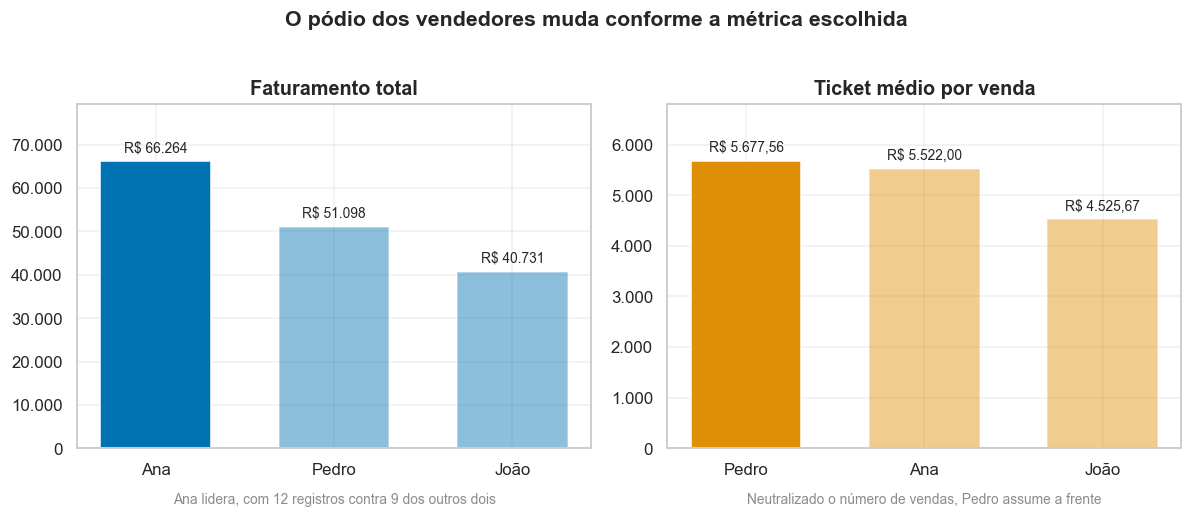

In [19]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6))

paineis = [
    (eixos[0], "faturamento", "Faturamento total",
     "Ana lidera, com 12 registros contra 9 dos outros dois", AZUL, 0),
    (eixos[1], "ticket_medio", "Ticket médio por venda",
     "Neutralizado o número de vendas, Pedro assume a frente", LARANJA, 2),
]

for eixo, coluna, titulo, subtitulo, cor, casas in paineis:
    serie = por_vendedor[coluna].sort_values(ascending=False)
    barras = eixo.bar(serie.index, serie.values, color=cor, width=0.62)
    eixo.bar_label(barras, labels=[reais(v, casas) for v in serie.values], padding=4, fontsize=9)

    # Destaca o líder do painel deixando os demais em tom mais fraco
    for barra, nome in zip(barras, serie.index):
        if nome != serie.idxmax():
            barra.set_alpha(0.45)

    eixo.set_title(titulo)
    eixo.set_xlabel(subtitulo, fontsize=9, color=CINZA, labelpad=10)
    eixo.set_ylim(0, serie.max() * 1.20)
    eixo.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))

fig.suptitle("O pódio dos vendedores muda conforme a métrica escolhida",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

À esquerda, Ana parece a melhor vendedora com folga; à direita, com a mesma base, ela cai
para segundo. A diferença entre os painéis é inteiramente explicada pelas 3 vendas a mais
que a construção do conjunto entregou a ela.

### 4.2 Composição do faturamento por região

Mapa de calor em vez de barras agrupadas porque o mais importante aqui não são os
valores, e sim **quais combinações existem**: o espaço em branco comunica ausência melhor
que uma barra de altura zero.

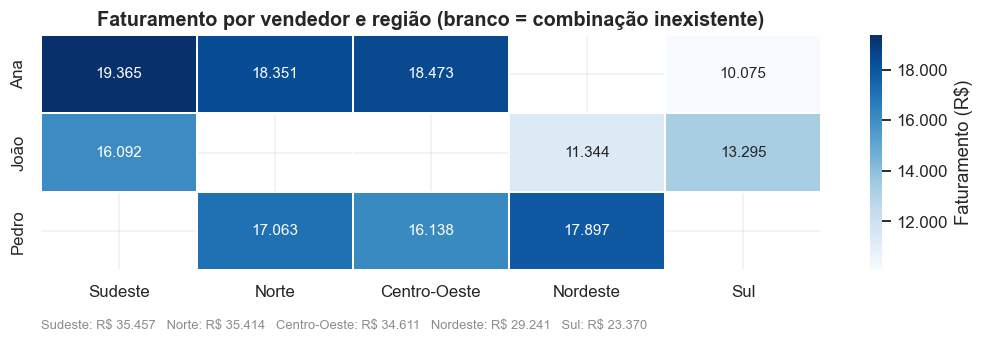

In [20]:
mapa = df_vendas.pivot_table(values="Vendas", index="Vendedor", columns="Regiao", aggfunc="sum")
mapa = mapa[por_regiao.index]   # colunas ordenadas por faturamento total

# Célula vazia quando a combinação não existe nos dados
rotulos = mapa.map(lambda v: "" if pd.isna(v) else f"{v:,.0f}".replace(",", "."))

fig, eixo = plt.subplots(figsize=(9.5, 3.4))
sns.heatmap(mapa, annot=rotulos, fmt="", cmap="Blues", linewidths=1.2, linecolor="white",
            cbar_kws={"label": "Faturamento (R$)"}, annot_kws={"fontsize": 10}, ax=eixo)
eixo.set_title("Faturamento por vendedor e região (branco = combinação inexistente)")
eixo.set_xlabel("")
eixo.set_ylabel("")
eixo.collections[0].colorbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))

# Totais por região na base, para a leitura da pergunta 2
eixo.text(0, 3.75, "   ".join(f"{r}: {reais(v)}" for r, v in por_regiao.items()),
          fontsize=8.5, color=CINZA, transform=eixo.transData)
plt.tight_layout()
plt.show()

Cinco das quinze células estão vazias: Ana nunca vende no Nordeste, João nunca no Norte
nem no Centro-Oeste, Pedro nunca no Sul nem no Sudeste. Não é um dado de negócio, é
consequência de os ciclos das listas (10 vendedores, 5 regiões) se encaixarem sempre do
mesmo jeito. Nos totais da base, as três primeiras regiões praticamente empatam, e só o
Sul se descola, 34,1% abaixo do Sudeste.

### 4.3 Distribuição dos valores de venda

Histograma e diagrama de caixa no mesmo eixo horizontal: o primeiro mostra o formato, o
segundo resume os quartis, e os pontos lembram que são apenas 30 observações.

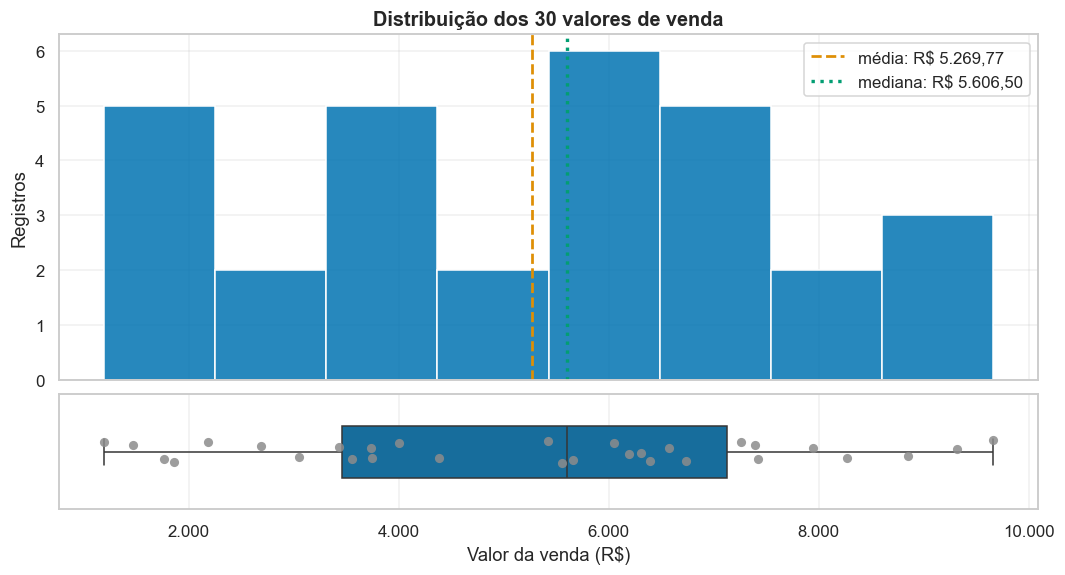

Média R$ 5.269,77 e mediana R$ 5.606,50 diferem em 6,0%. Outliers: 0


In [21]:
vendas = df_vendas["Vendas"]
media, mediana = vendas.mean(), vendas.median()

fig, (topo, base) = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True,
                                 gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})

sns.histplot(vendas, bins=8, color=AZUL, edgecolor="white", alpha=0.85, ax=topo)
topo.axvline(media, color=LARANJA, linestyle="--", linewidth=1.8, label=f"média: {reais(media, 2)}")
topo.axvline(mediana, color=VERDE, linestyle=":", linewidth=2.2, label=f"mediana: {reais(mediana, 2)}")
topo.set_title("Distribuição dos 30 valores de venda")
topo.set_ylabel("Registros")
topo.set_xlabel("")
topo.legend(frameon=True)

sns.boxplot(x=vendas, color=AZUL, width=0.45, fliersize=0, ax=base)
sns.stripplot(x=vendas, color=CINZA, size=6, alpha=0.85, jitter=0.10, ax=base)
base.set_xlabel("Valor da venda (R$)")
base.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))

# Sem tight_layout: ele desfaria o hspace estreito que mantém os dois painéis colados
fig.subplots_adjust(left=0.09, right=0.98, top=0.92, bottom=0.12)
plt.show()

q1, q3 = vendas.quantile([0.25, 0.75])
print(f"Média {reais(media, 2)} e mediana {reais(mediana, 2)} diferem em "
      f"{pct(abs(media - mediana) / mediana)}. "
      f"Outliers: {((vendas < q1 - 1.5 * (q3 - q1)) | (vendas > q3 + 1.5 * (q3 - q1))).sum()}")

Média e mediana quase coincidem e não há nenhum ponto fora dos limites do diagrama de
caixa: é o retrato de uma distribuição **uniforme**, que é o que
`np.random.randint(1000, 10000, 30)` produz. Faturamento real quase nunca se parece com
isso, e costuma ser assimétrico à direita, com média bem acima da mediana. As
irregularidades do histograma são ruído amostral de 30 observações em 8 faixas.

---

# 5. 📋 Conclusões

| Pergunta | Resposta | Ressalva |
|---|---|---|
| 1. Vendedor com maior número de vendas | **Ana** em volume: 12 vendas, R$ 66.264, 156 unidades. **Pedro** em ticket médio: R$ 5.677,56 | A vantagem de Ana vem das 3 vendas a mais que a construção lhe deu |
| 2. Região com maior faturamento total | **Sudeste**, R$ 35.457 (22,4% do total) | Fica 0,12% à frente do Norte; a simulação mostra que é ruído |
| 3. Produto mais vendido em quantidade | **Notebook**, 70 unidades | Não é o que mais fatura: valor e quantidade são independentes aqui |
| 4. Média de vendas por vendedor | Pedro R$ 5.677,56, Ana R$ 5.522,00, João R$ 4.525,67 | Média geral de R$ 5.269,77 |

Na limpeza, as duas decisões que mais mudaram o resultado foram **padronizar o texto
antes de deduplicar**, provado por contrafactual na seção 3.3, e **converter as datas
formato a formato** em vez de confiar em `format="mixed"`, cujo tratamento das datas ISO
muda conforme a versão do pandas.

## Limitações

1. **Os dados de vendas são sintéticos.** Nada aqui descreve vendedores, produtos ou
   regiões de verdade.
2. **`Produto` e `Regiao` são redundantes**, então não há como separar o efeito de uma do
   efeito da outra.
3. **A amostra é minúscula**: 30 registros, 6 por região e de 9 a 12 por vendedor. Quase
   nenhuma diferença observada sobrevive a um segundo sorteio.
4. **O cadastro do Desafio 2 também é inventado.** Os defeitos são realistas; as pessoas
   e os valores, não.
5. **Os valores preenchidos não são medições.** A mediana das idades e o rótulo
   `"Não informado"` marcam onde falta dado e devem continuar sendo tratados assim.

---

**Reprodutibilidade:** `np.random.seed(42)` nos dados da aula, semente 0 na simulação e
data de referência fixa nas colunas derivadas.